# Mapping wildfire-policy coverage across Europe

## 1. Setup

### 1.2 Required imports and paths

In [ ]:
'''
from pathlib import Path
from pypdf import PdfReader
import fitz  
import sys
import os
import re
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from rasterio.crs import CRS
'''

import fitz  
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import pandas as pd
import pycountry
import re
import sys

from pathlib import Path
from pypdf import PdfReader
from rasterio.crs import CRS

ROOT_DIR = Path.cwd()

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

PATH_DATA = ROOT_DIR / 'Data'
PATH_RAW = PATH_DATA / 'Raw'
PATH_PROCESSED = PATH_DATA / 'Processed'
PATH_OUTPUTS = ROOT_DIR / 'Outputs'

eu_report_path = PATH_RAW / 'Forestfires_report_EU.pdf'

TARGET_CRS = CRS.from_epsg(3035)

input_paths = [eu_report_path]
pd.DataFrame({'file': [str(p) for p in input_paths], 'exists': [p.exists() for p in input_paths]})

,file,exists
0,/Users/maxlengenfelder/Desktop/FS26/GEO888/GEO...,True


### 1.3 Loading in EU-Wildfire report 

In [2]:
reader = PdfReader(eu_report_path)

print(len(reader.pages))

page = reader.pages[0]

print(page.extract_text())

277
 
 
 
 
 
 
 
 
 
Joint Research Centre  
Forest Fires in Europe,  
Middle East and North Africa 
2024 
2025 


### 1.4 Create a text-file for each country, based on page numbers

In [ ]:
countries = [
    ("Austria", 14),
    ("Belgium", 18),
    ("Bulgaria", 19),
    ("Croatia", 20),
    ("Cyprus", 22),
    ("Czech Republic", 25),
    ("Estonia", 28),
    ("Finland", 30),
    ("France", 34),
    ("Germany", 43),
    ("Greece", 46),
    ("Hungary", 51),
    ("Ireland", 55),
    ("Italy", 58),
    ("Latvia", 73),
    ("Lithuania", 76),
    ("The Netherlands", 80),
    ("Norway", 85),
    ("Poland", 90),
    ("Portugal", 99),
    ("Republic of North Macedonia", 111),
    ("Romania", 117),
    ("Serbia", 122),
    ("Slovakia", 126),
    ("Slovenia", 131),
    ("Spain", 135),
    ("Sweden", 145),
    ("Switzerland", 151),
    ("Türkiye", 153),
    ("Ukraine", 162),
    ("United Kingdom", 173)
]

output_dir = PATH_PROCESSED / "country_texts"
output_dir.mkdir(parents=True, exist_ok=True)

doc = fitz.open(eu_report_path)

PAGE_OFFSET = 2

# Extraction
for i in range(len(countries)):

    country, start_page = countries[i]

    if i < len(countries) - 1:
        end_page = countries[i + 1][1] - 1
    else:
        end_page = len(doc)

    start = start_page - 1 + PAGE_OFFSET
    end = end_page + PAGE_OFFSET

    print(f"Processing {country}: pages {start}-{end}")

    full_text = ""

    for page_num in range(start, end):

        if page_num < 0 or page_num >= len(doc):
            continue

        page = doc.load_page(page_num)

        # Better extraction
        text = page.get_text("text", sort=True)

        full_text += text + "\n"

    safe_name = re.sub(r'[\\/*?:"<>|]', "", country)

    with open(os.path.join(output_dir, f"{safe_name}.txt"), "w", encoding="utf-8") as f:
        f.write(full_text)

print("\nDone!")
print(f"Files saved in: {output_dir}")

Processing Austria: pages 15-19
Processing Belgium: pages 19-20
Processing Bulgaria: pages 20-21
Processing Croatia: pages 21-23
Processing Cyprus: pages 23-26
Processing Czech Republic: pages 26-29
Processing Estonia: pages 29-31
Processing Finland: pages 31-35
Processing France: pages 35-44
Processing Germany: pages 44-47
Processing Greece: pages 47-52
Processing Hungary: pages 52-56
Processing Ireland: pages 56-59
Processing Italy: pages 59-74
Processing Latvia: pages 74-77
Processing Lithuania: pages 77-81
Processing The Netherlands: pages 81-86
Processing Norway: pages 86-91
Processing Poland: pages 91-100
Processing Portugal: pages 100-112
Processing Republic of North Macedonia: pages 112-118
Processing Romania: pages 118-123
Processing Serbia: pages 123-127
Processing Slovakia: pages 127-132
Processing Slovenia: pages 132-136
Processing Spain: pages 136-146
Processing Sweden: pages 146-152
Processing Switzerland: pages 152-154
Processing Türkiye: pages 154-163
Processing Ukraine

### 1.5 Searching for keywords and counting

In [4]:
TEXT_FOLDER = PATH_PROCESSED / "country_texts"

keywords = [
    "Prevention",
    "Adaptation",
    "Strategy",
    "Research activities",
    "Wildfire management",
    "Awareness campaigns",
    "Information campaigns"
]

results = []

for filepath in TEXT_FOLDER.glob("*.txt"):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read().lower()

    row = {
        "Country": filepath.stem  # .stem automatically removes the .txt extension
    }

    sentences = re.split(r"[.!?\n]", text)

    for kw in keywords:
        kw_lower = kw.lower()
        found = any(kw_lower in s for s in sentences)
        row[kw] = "Yes" if found else "No"

    # COUNT YES
    yes_count = sum(1 for kw in keywords if row[kw] == "Yes")
    row["Yes_Count"] = yes_count

    # CLASSIFICATION (3 groups)
    if yes_count <= 1:
        row["Group"] = "Low"
    elif yes_count <= 2:
        row["Group"] = "Medium"
    else:
        row["Group"] = "High"

    results.append(row)

wildfire_df = pd.DataFrame(results)

print(wildfire_df.head())

excel_path = PATH_PROCESSED / "keyword_classification3.xlsx"
wildfire_df.to_excel(excel_path, index=False)

print(f"\nSaved: {excel_path}")

                       Country Prevention Adaptation Strategy  \
0                       Greece        Yes         No       No   
1                       Sweden        Yes         No       No   
2  Republic of North Macedonia        Yes        Yes       No   
3                      Belgium        Yes         No       No   
4                       Cyprus        Yes         No       No   

  Research activities Wildfire management Awareness campaigns  \
0                  No                  No                  No   
1                  No                  No                  No   
2                  No                  No                  No   
3                  No                  No                  No   
4                  No                  No                  No   

  Information campaigns  Yes_Count   Group  
0                   Yes          2  Medium  
1                    No          1     Low  
2                    No          2  Medium  
3                    No          1    

### 1.6 Loading wildfire-policy classification (excel) as dataframe

In [5]:
wildfire_df = pd.read_excel(excel_path)

## 2. Data processing

### 2.1 Adjusting columns for join

In [6]:
iso_map = {
    "Austria": "AUT",
    "Belgium": "BEL",
    "Bulgaria": "BGR",
    "Croatia": "HRV",
    "Cyprus": "CYP",
    "Czechia": "CZE",
    "Denmark": "DNK",
    "Estonia": "EST",
    "Finland": "FIN",
    "France": "FRA",
    "Germany": "DEU",
    "Greece": "GRC",
    "Hungary": "HUN",
    "Ireland": "IRL",
    "Italy": "ITA",
    "Latvia": "LVA",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Malta": "MLT",
    "The Netherlands": "NLD",
    "Norway": "NOR",
    "Poland": "POL",
    "Portugal": "PRT",
    "Romania": "ROU",
    "Slovakia": "SVK",
    "Slovenia": "SVN",
    "Spain": "ESP",
    "Sweden": "SWE",
    "Switzerland": "CHE",
    "United Kingdom": "GBR",
    "Turkey": "TUR"
}

iso_map.update({
    "Czech Republic": "CZE",
    "Republic of North Macedonia": "MKD",
    "The Netherlands": "NLD",
    "Türkiye": "TUR"
})

wildfire_df["ISO3"] = wildfire_df["Country"].map(iso_map)

### 2.2 Loading in worldmap

In [7]:
world = gpd.read_file(
    "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")

### 2.3 Standardize ISO3

In [8]:
def to_iso3(x):
    try:
        return pycountry.countries.lookup(x).alpha_3
    except:
        return None

wildfire_df["ISO3"] = wildfire_df["Country"].apply(to_iso3)
world["ISO3"] = world["NAME"].apply(to_iso3)

### 2.4 Merge wildfire_df & world_df

In [9]:
gdf = world.merge(
    wildfire_df,
    on="ISO3",
    how="left")

## 3. Data visualization

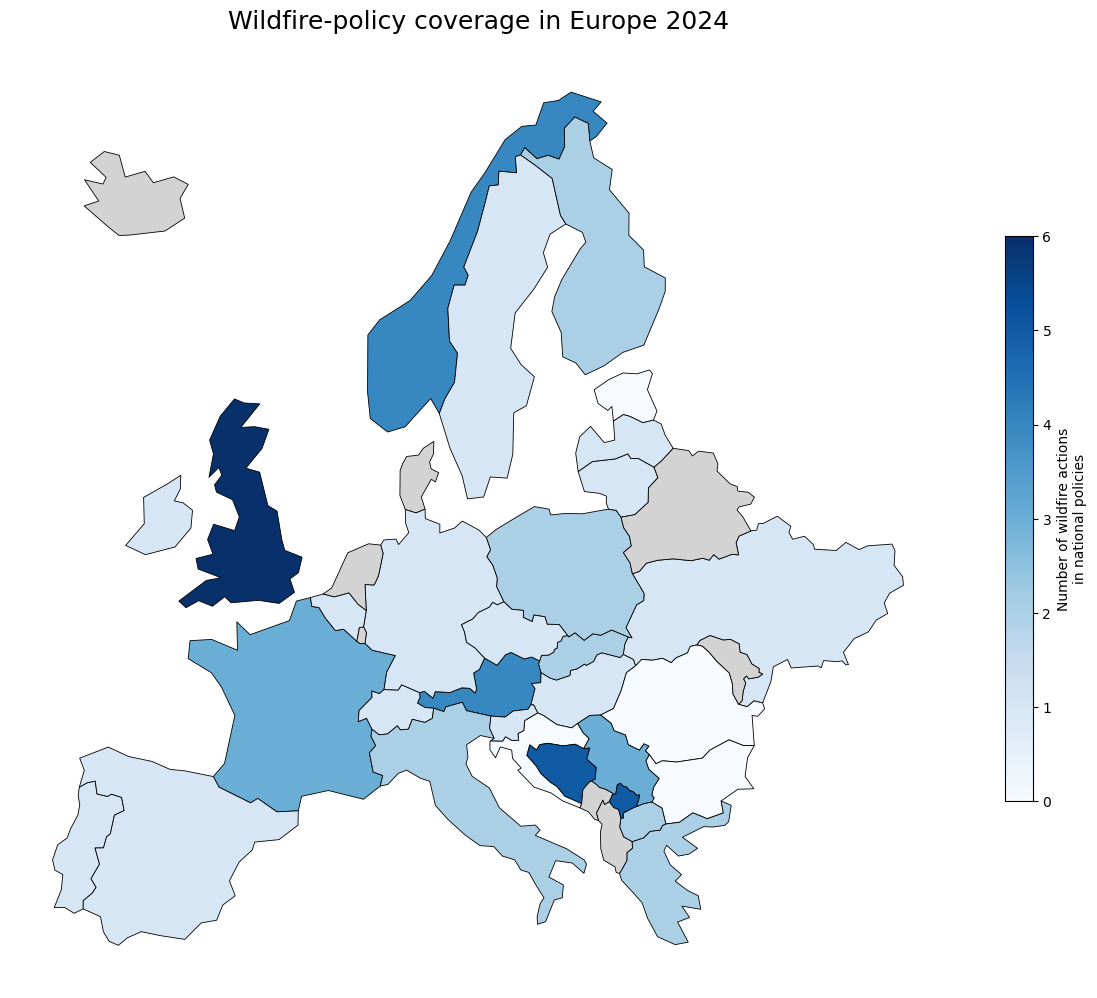

Map successfully saved to: /Users/maxlengenfelder/Desktop/FS26/GEO888/GEO888_Wildfire_Indicator/Outputs/Wildfire_policy_coverage.png
All Outputs saved!
GPKG: /Users/maxlengenfelder/Desktop/FS26/GEO888/GEO888_Wildfire_Indicator/Data/Processed


In [10]:
# Keep Europe only
gdf = gdf[gdf["CONTINENT"] == "Europe"].copy()

# Remove Russia
gdf = gdf[gdf["NAME"] != "Russia"]

# CRS!!! 
gdf = gdf.to_crs(TARGET_CRS)

# Remove islands properly (Spain, France, etc.)
gdf["geometry"] = gdf.geometry.apply(
    lambda geom: max(geom.geoms, key=lambda g: g.area)
    if geom.geom_type == "MultiPolygon"
    else geom
)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))

gdf.plot(
    column="Yes_Count",
    cmap="Blues",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    missing_kwds={"color": "lightgrey"},
    ax=ax,
    legend_kwds={
        "label": "Number of wildfire actions\nin national policies",
        "shrink": 0.6
    }
)
ax.set_axis_off()
ax.set_title(
    "Wildfire-policy coverage in Europe 2024",
    fontsize=18,
    pad=15
)
plt.tight_layout()
out_map_path = PATH_OUTPUTS / 'Wildfire_policy_coverage.png'
fig.savefig(out_map_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Save gdf as GPKG
gdf.to_file(PATH_PROCESSED / 'policy_layer.gpkg', driver='GPKG')

print(f"Map successfully saved to: {out_map_path}")
print('All Outputs saved!')
print('GPKG:', PATH_PROCESSED)